# Droplet Swimming

## A Note on Prompt Frames
The original author's scripts (`2_fframe_segmentation.py`, `3_swim_hdsegmentation.py`) used a **synthetic "prompt frame"** strategy: a reference JPEG image with a worm at a known pixel location was appended as the last frame (frame 300) of each video directory. SAM2 was then told "there's a worm at these coordinates in frame 300" and segmentation was propagated **backward** through the real video frames. This avoided manually prompting each video — the same reference image and hardcoded coordinates worked for all of them. For HD segmentation, three different prompt images were used depending on the crop size (110×110 vs. 800×800), each with their own hardcoded click coordinates.

**The problem:** These prompt frame images were never committed to the repository. They are referenced only by `PATH_TO_GENERIC_PROMPT_FRAME` and `PATH_TO_PROMPT_FRAME` placeholders, meaning they only existed on the original author's local machine.

**Our fix:** Instead of requiring external reference images, this notebook prompts **directly on a real frame** from the video (e.g., the middle frame) and propagates in both directions. This is simpler, doesn't require mystery assets, and follows the standard SAM2 workflow. The only requirement is that you pick a frame where the worm is clearly visible and provide its `(x, y)` pixel coordinates.

## Notebook Setup
In this section, we'll set ourselves up for success by setting up our Python environment appropriately, importing the Python libraries we'll be using, and downloading the raw data from Google Drive.

In [1]:
# Importing the necessary Python libraries
from __future__ import annotations

import gc
import os
import pickle
import re
import shutil
import zipfile
from collections import Counter, defaultdict
from pathlib import Path

import cv2
import gdown
import h5py
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import tifffile
import torch
from PIL import Image
from scipy import interpolate, ndimage
from scipy.ndimage import binary_dilation
from scipy.signal import find_peaks, savgol_filter, welch
from scipy.spatial.distance import cdist
from skimage import graph, measure, morphology
from tqdm import tqdm

from sam2.build_sam import build_sam2_video_predictor_hf

In [2]:
# Setting the root of the working directory
WORK_DIR_ROOT = '..'

# Setting the working directories used throughout this notebook
raw_files_dir = f'{WORK_DIR_ROOT}/data/raw_files'
processed_files_dir = f'{WORK_DIR_ROOT}/data/processed_files/droplet_swimming'
frames_dir = Path(processed_files_dir) / 'frames'
segmentation_dir = Path(processed_files_dir) / 'segmentation'
hd_segmentation_dir = Path(processed_files_dir) / 'hd_segmentation'
shape_analysis_dir = Path(processed_files_dir) / 'shape_analysis'
plots_dir = Path(processed_files_dir) / 'plots'
prompt_frames_dir = Path(processed_files_dir) / 'prompt_frames'

# Creating required directories (if not already created)
os.makedirs(raw_files_dir, exist_ok=True)
for d in [frames_dir, segmentation_dir, hd_segmentation_dir, shape_analysis_dir,
          plots_dir, prompt_frames_dir]:
    d.mkdir(parents=True, exist_ok=True)

## Downloading the Raw TIFF Files

In [3]:
# Setting the raw Google Drive doc ID and file URL
RAW_FILE_DOC_ID = '1UTYRcgheRP1eMXw71CNgh9-em2MigdDb'
gdrive_file_url = f'https://drive.google.com/uc?id={RAW_FILE_DOC_ID}'

# Checking whether raw files are already present (ignoring .gitkeep)
existing_raw_files = [
    path for path in Path(raw_files_dir).iterdir() if path.name != '.gitkeep'
]

# Downloading and extracting only when the raw files directory is empty or only has .gitkeep
if not existing_raw_files:

    # Downloading the raw files from Google Drive
    gdown.download(
        url = gdrive_file_url,
        output = f'{raw_files_dir}/samples.zip'
    )

    # Setting the .zip filepath
    zip_path = Path(f'{raw_files_dir}/samples.zip')

    # Setting the prefix associated to all the raw TIF files
    RAW_FILE_PREFIX = "06.27.25 CONFOCAL VID_DYS1AH DAY 5 CRAWL "

    # Interacting with the ZIP file downloaded from Google Drive
    with zipfile.ZipFile(zip_path) as z:

        # Iterating over each TIF file in the raw ZIP
        for member in z.namelist():

            # Checking if the file is in the "sample images/" directory and ends with ".tif"
            if member.startswith('sample images/') and member.endswith('.tif'):

                # Getting the original name of the file
                original_name = Path(member).name

                # Setting a new name for the file by stripping the prefix from the file
                new_name = original_name.replace(RAW_FILE_PREFIX, '', 1)

                # Extracting the contents of the file from the ZIP
                target = zip_path.parent / new_name
                with z.open(member) as src, open(target, 'wb') as destination:
                    destination.write(src.read())

    # Deleting the original ZIP file as it is no longer needed
    zip_path.unlink()
else:
    print('Raw files already exist in raw_files_dir; skipping download and extraction.')

Raw files already exist in raw_files_dir; skipping download and extraction.


## Processing TIFFs into JPEG Frame Directories
Each raw TIFF stack is converted into a dedicated directory of numbered JPEG frames. Global min/max normalization is applied across all frames within each stack to preserve relative brightness.

In [4]:
# Checking whether processed frame directories already exist (ignoring .gitkeep)
existing_processed_files = [
    path for path in Path(frames_dir).iterdir()
    if path.name != '.gitkeep'
]

# Processing raw TIFF files only when the processed directory is empty
if not existing_processed_files:

    # Iterating over all raw TIFF files
    for raw_file_name in sorted(os.listdir(raw_files_dir)):

        # Skipping non-TIFF files
        if not raw_file_name.lower().endswith(('.tif', '.tiff')):
            continue

        tiff_path = os.path.join(raw_files_dir, raw_file_name)

        with tifffile.TiffFile(tiff_path) as tif:
            total_frames = len(tif.pages)
            if total_frames == 0:
                print(f'Skipping {raw_file_name}: empty TIFF')
                continue

            # Computing global min/max across all frames for consistent brightness normalization
            global_min = float('inf')
            global_max = float('-inf')
            for page in tif.pages:
                frame = page.asarray()
                global_min = min(global_min, float(np.min(frame)))
                global_max = max(global_max, float(np.max(frame)))

            # Creating an output directory named after the TIFF stem
            raw_file_stem = Path(raw_file_name).stem
            video_output_dir = frames_dir / raw_file_stem
            video_output_dir.mkdir(parents=True, exist_ok=True)

            # Exporting each frame as a globally-normalized JPEG
            for frame_idx in range(total_frames):
                frame = tif.pages[frame_idx].asarray()

                if global_max == global_min:
                    frame_8bit = np.zeros_like(frame, dtype=np.uint8)
                else:
                    frame_adjusted = frame.astype(np.float64) - global_min
                    scaling_factor = 255.0 / (global_max - global_min)
                    frame_8bit = (frame_adjusted * scaling_factor).astype(np.uint8)

                # Converting grayscale to BGR for consistent JPEG output
                if frame_8bit.ndim == 2:
                    frame_8bit = cv2.cvtColor(frame_8bit, cv2.COLOR_GRAY2BGR)

                dest_path = video_output_dir / f'{frame_idx:06d}.jpg'
                cv2.imwrite(str(dest_path), frame_8bit, [cv2.IMWRITE_JPEG_QUALITY, 95])

            print(f'Converted {raw_file_name}: {total_frames} frames -> {video_output_dir.name}/')
else:
    print('Processed frame directories already exist; skipping TIFF-to-JPEG conversion.')

Converted 5_t065_ch01.tif: 1 frames -> 5_t065_ch01/
Converted 5_t065_ch02.tif: 1 frames -> 5_t065_ch02/
Converted 5_t065_ch03.tif: 1 frames -> 5_t065_ch03/
Converted 5_t066_ch00.tif: 1 frames -> 5_t066_ch00/
Converted 5_t066_ch01.tif: 1 frames -> 5_t066_ch01/
Converted 5_t066_ch02.tif: 1 frames -> 5_t066_ch02/
Converted 5_t066_ch03.tif: 1 frames -> 5_t066_ch03/
Converted 5_t067_ch00.tif: 1 frames -> 5_t067_ch00/
Converted 5_t067_ch01.tif: 1 frames -> 5_t067_ch01/
Converted 5_t067_ch02.tif: 1 frames -> 5_t067_ch02/
Converted 5_t067_ch03.tif: 1 frames -> 5_t067_ch03/
Converted 5_t068_ch00.tif: 1 frames -> 5_t068_ch00/
Converted 5_t068_ch01.tif: 1 frames -> 5_t068_ch01/
Converted 5_t068_ch02.tif: 1 frames -> 5_t068_ch02/
Converted 5_t068_ch03.tif: 1 frames -> 5_t068_ch03/
Converted 5_t069_ch00.tif: 1 frames -> 5_t069_ch00/
Converted 5_t069_ch01.tif: 1 frames -> 5_t069_ch01/
Converted 5_t069_ch02.tif: 1 frames -> 5_t069_ch02/
Converted 5_t069_ch03.tif: 1 frames -> 5_t069_ch03/
Converted 5_

In [5]:
# Listing all available video frame directories
video_dirs = sorted([
    d for d in frames_dir.iterdir()
    if d.is_dir() and d.name != '.gitkeep'
])

if not video_dirs:
    raise FileNotFoundError(
        f'No video frame directories found in: {frames_dir}'
    )

# Selecting the first available video directory for processing
video_frames_dir = video_dirs[0]
video_folder_name = video_frames_dir.name
print(f'Available video directories: {[d.name for d in video_dirs]}')
print(f'Selected test video: {video_folder_name}')

# Counting available frames
frame_names = sorted(
    [f for f in os.listdir(video_frames_dir) if f.lower().endswith(('.jpg', '.jpeg'))],
    key=lambda p: int(os.path.splitext(p)[0])
)
print(f'Total frames: {len(frame_names)}')

Available video directories: ['5_t065_ch01', '5_t065_ch02', '5_t065_ch03', '5_t066_ch00', '5_t066_ch01', '5_t066_ch02', '5_t066_ch03', '5_t067_ch00', '5_t067_ch01', '5_t067_ch02', '5_t067_ch03', '5_t068_ch00', '5_t068_ch01', '5_t068_ch02', '5_t068_ch03', '5_t069_ch00', '5_t069_ch01', '5_t069_ch02', '5_t069_ch03', '5_t070_ch00', '5_t070_ch01', '5_t070_ch02', '5_t129_ch02', '5_t129_ch03', '5_t130_ch00', '5_t130_ch01', '5_t130_ch02', '5_t130_ch03', '5_t131_ch00', '5_t131_ch01', '5_t131_ch02', '5_t131_ch03', '5_t132_ch00', '5_t132_ch01', '5_t132_ch02', '5_t132_ch03', '5_t133_ch00', '5_t133_ch01', '5_t133_ch02', '5_t133_ch03', '5_t134_ch00', '5_t134_ch01', '5_t134_ch02', '5_t134_ch03']
Selected test video: 5_t065_ch01
Total frames: 1


### Loading a Test Frame

Sample frame: 000000.jpg
Frame size: (128, 128)


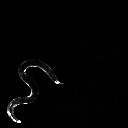

In [6]:
# Loading a sample frame from the middle of the selected video for visualization
sample_frame_path = os.path.join(str(video_frames_dir), frame_names[len(frame_names) // 2])
sample_frame = cv2.imread(sample_frame_path)

if sample_frame is None:
    raise FileNotFoundError(f'Could not load sample frame: {sample_frame_path}')

print(f'Sample frame: {frame_names[len(frame_names) // 2]}')
print(f'Frame size: {sample_frame.shape[:2]}')
Image.fromarray(cv2.cvtColor(sample_frame, cv2.COLOR_BGR2RGB))

## Autoprompted Segmentation with SAM2
Using Meta's SAM2 video predictor, we perform two-pass segmentation: first a full-frame pass using a generic prompt frame, then a high-definition pass on cropped regions around the detected worm.

### Loading the SAM2 Video Predictor from Hugging Face

In [7]:
# Detecting the hardware device
if torch.cuda.is_available():
    device = torch.device('cuda')
    torch.autocast(device_type='cuda', dtype=torch.bfloat16).__enter__()
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Current hardware device type: {device}')

# Loading the SAM2 video predictor from Hugging Face
predictor = build_sam2_video_predictor_hf('facebook/sam2.1-hiera-large', device=device)

Current hardware device type: mps


### Creating Helper Functions for Segmentation

In [8]:
# Rendering a colored mask overlay on a matplotlib axis
def show_mask(mask, ax, obj_id=None, random_color=False):
    color = (np.concatenate([np.random.random(3), np.array([0.6])], axis=0) if random_color
             else np.array([*plt.get_cmap('tab10')(0 if obj_id is None else obj_id)[:3], 0.6]))
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)


# Rendering prompt points (positive/negative) on a matplotlib axis
def show_points(coords, labels, ax, marker_size=20):
    pos_points = coords[labels == 1]
    neg_points = coords[labels == 0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*',
               s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*',
               s=marker_size, edgecolor='white', linewidth=1.25)

### Full-Frame Segmentation
A generic prompt frame is appended to the end of the video directory. SAM2 segments backward from that prompt frame to produce per-frame masks for the entire video.

In [ ]:
# Full-frame segmentation by prompting directly on an existing video frame
def segment_fframe_video(video_dir, prompt_frame_idx, prompt_point, segmentation_dir):
    """Run full-frame segmentation on a video directory by clicking on an existing frame."""

    # Building the sorted frame list
    frame_names = sorted(
        [p for p in os.listdir(video_dir) if os.path.splitext(p)[-1].lower() in ['.jpg', '.jpeg']],
        key=lambda p: int(os.path.splitext(p)[0])
    )

    # Initializing SAM2 inference state
    inference_state = predictor.init_state(video_path=video_dir)

    # Adding a click prompt on the specified frame
    ann_obj_id = 1
    points = np.array([prompt_point], dtype=np.float32)
    labels = np.array([1], np.int32)

    _, out_obj_ids, out_mask_logits = predictor.add_new_points(
        inference_state=inference_state,
        frame_idx=prompt_frame_idx,
        obj_id=ann_obj_id,
        points=points,
        labels=labels,
    )

    # Visualizing the prompt frame
    plt.figure(figsize=(12, 8))
    plt.title(f'Prompt frame {prompt_frame_idx}')
    plt.imshow(Image.open(os.path.join(video_dir, frame_names[prompt_frame_idx])))
    show_points(points, labels, plt.gca())
    show_mask((out_mask_logits[0] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_ids[0])
    plt.show()

    # Propagating segmentation through all frames (both directions from the prompt)
    video_segments = {}
    for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state):
        video_segments[out_frame_idx] = {
            out_obj_id: (out_mask_logits[i] > 0.0).cpu().numpy()
            for i, out_obj_id in enumerate(out_obj_ids)
        }

    # Error flagging: empty frames, frames with very small or large predictions
    empty_frames = [f for f, obj in video_segments.items() if all(not m.any() for m in obj.values())]
    low_frames = [f for f, obj in video_segments.items() if 0 < sum(m.sum() for m in obj.values()) <= 200]
    high_frames = [f for f, obj in video_segments.items() if sum(m.sum() for m in obj.values()) >= 5000]

    print(f'Empty frames: {len(empty_frames)}' + (f' -> {empty_frames}' if empty_frames else ''))
    print(f'Low-detection frames (<=200 px): {len(low_frames)}' + (f' -> {low_frames}' if low_frames else ''))
    print(f'High-detection frames (>=5000 px): {len(high_frames)}' + (f' -> {high_frames}' if high_frames else ''))

    # Saving the full-frame segmentation as a pickle file
    save_path = segmentation_dir / f'{Path(video_dir).name}_fframe_segmentation.pkl'
    with open(save_path, 'wb') as f:
        pickle.dump(video_segments, f)
    print(f'Saved full-frame segmentation: {save_path}')

    # Resetting predictor state
    predictor.reset_state(inference_state)
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return video_segments

In [ ]:
# Running full-frame segmentation on the selected video
# NOTE: Update prompt_frame_idx to a frame where the worm is clearly visible,
#       and prompt_point to the (x, y) pixel coordinates of the worm in that frame.
prompt_frame_idx = len(frame_names) // 2  # Middle frame as a starting point
prompt_point = [1150, 1175]               # Click coordinates on the prompt frame (x, y)

fframe_segments = segment_fframe_video(
    video_dir=str(video_frames_dir),
    prompt_frame_idx=prompt_frame_idx,
    prompt_point=prompt_point,
    segmentation_dir=segmentation_dir,
)

FileNotFoundError: [Errno 2] No such file or directory: '../data/processed_files/droplet_swimming/prompt_frames/prompt_fframe.jpg'

### High-Definition Segmentation
Following the full-frame pass, we crop tightly around the detected worm and run SAM2 again at higher resolution. If the initial crop is too large (e.g. due to empty masks), an intermediate 800×800 crop pass is performed before the final 110×110 HD pass.

In [ ]:
# Computing fixed crop windows centered on the detected masks
def calculate_fixed_crop_window(video_segments, original_size, crop_size):
    """Create fixed-sized crop windows centered on the mask centroid for each frame."""
    orig_height, orig_width = original_size
    centers = []
    empty_masks = 0

    for frame_num in sorted(video_segments.keys()):
        mask = next(iter(video_segments[frame_num].values()))
        y_coords, x_coords = np.where(mask[0])

        if len(x_coords) > 0 and len(y_coords) > 0:
            center_x = (x_coords.min() + x_coords.max()) // 2
            center_y = (y_coords.min() + y_coords.max()) // 2
            centers.append((center_x, center_y))
        else:
            empty_masks += 1
            centers.append((orig_width // 2, orig_height // 2))

    # If there are empty masks, use average center and a larger 800x800 crop for a double pass
    if empty_masks > 0:
        crop_size = 800
        avg_cx = sum(c[0] for c in centers) // len(centers)
        avg_cy = sum(c[1] for c in centers) // len(centers)
        centers = [(avg_cx, avg_cy)] * len(centers)

    crop_windows = []
    for center_x, center_y in centers:
        left = max(0, center_x - crop_size // 2)
        top = max(0, center_y - crop_size // 2)
        right = min(orig_width, left + crop_size)
        bottom = min(orig_height, top + crop_size)

        if right == orig_width:
            left = right - crop_size
        if bottom == orig_height:
            top = bottom - crop_size

        crop_windows.append((left, top, right, bottom))

    return crop_windows, (crop_size, crop_size), empty_masks


# Cropping video frames using the computed fixed crop windows
def process_frames_fixed_crop(input_folder, output_folder, video_segments, original_size, crop_size=110):
    """Crop each frame using a fixed window derived from the segmentation masks."""
    frame_files = sorted([f for f in os.listdir(input_folder) if f.endswith('.jpg')])
    if not frame_files:
        raise ValueError('No jpg files found in the input folder')

    os.makedirs(output_folder, exist_ok=True)

    crop_windows, (crop_h, crop_w), empty_masks = calculate_fixed_crop_window(
        video_segments, original_size, crop_size
    )

    print(f'Empty masks: {empty_masks}/{len(video_segments)}')
    print(f'Crop size: {crop_h}x{crop_w}')

    for idx, frame_file in enumerate(tqdm(frame_files, desc='Cropping frames')):
        frame = cv2.imread(os.path.join(input_folder, frame_file))
        left, top, right, bottom = crop_windows[idx]
        cropped = frame[top:bottom, left:right]

        if cropped.shape[:2] != (crop_h, crop_w):
            cropped = cv2.resize(cropped, (crop_w, crop_h))

        cv2.imwrite(os.path.join(output_folder, frame_file), cropped)

    return len(frame_files), (crop_h, crop_w)

In [ ]:
# HD segmentation: crop around worm, run SAM2 again at higher resolution
def swim_hdsegmentation(video_dir, fframe_segments, prompt_frame_idx, prompt_point,
                        hd_segmentation_dir, temp_crop_root, crop_size=110):
    """
    Perform HD segmentation by cropping frames around the detected worm and re-running SAM2.
    If the initial crop yields 800x800 (due to empty masks), an intermediate pass is done,
    followed by a final 110x110 HD pass.
    """

    # Reading one frame to get the original dimensions
    frame_files = sorted([f for f in os.listdir(video_dir) if f.endswith('.jpg')])
    first_frame = cv2.imread(os.path.join(video_dir, frame_files[0]))
    original_size = first_frame.shape[:2]

    # Creating temporary crop directory
    temp_cropdir = temp_crop_root / f'{Path(video_dir).name}_crop'
    if temp_cropdir.exists():
        shutil.rmtree(temp_cropdir)
    temp_cropdir.mkdir(parents=True, exist_ok=True)

    num_frames, actual_crop_size = process_frames_fixed_crop(
        video_dir, str(temp_cropdir), fframe_segments, original_size, crop_size=crop_size
    )
    print(f'Processed {num_frames} frames. Crop size: {actual_crop_size[1]}x{actual_crop_size[0]}')

    # Building the frame list and initializing SAM2
    frame_names = sorted(
        [p for p in os.listdir(str(temp_cropdir)) if os.path.splitext(p)[-1].lower() in ['.jpg', '.jpeg']],
        key=lambda p: int(os.path.splitext(p)[0])
    )
    inference_state = predictor.init_state(video_path=str(temp_cropdir))

    # Adding click prompt on the specified frame
    ann_obj_id = 1
    points = np.array([prompt_point], dtype=np.float32)
    labels = np.array([1], np.int32)

    _, out_obj_ids, out_mask_logits = predictor.add_new_points(
        inference_state=inference_state,
        frame_idx=prompt_frame_idx,
        obj_id=ann_obj_id,
        points=points,
        labels=labels,
    )

    # Visualizing the prompt
    plt.figure(figsize=(8, 8))
    plt.title(f'HD prompt frame {prompt_frame_idx} (crop {actual_crop_size[0]}x{actual_crop_size[1]})')
    plt.imshow(Image.open(os.path.join(str(temp_cropdir), frame_names[prompt_frame_idx])))
    show_points(points, labels, plt.gca())
    show_mask((out_mask_logits[0] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_ids[0])
    plt.show()

    # Propagating segmentation through all frames
    video_segments = {}
    for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state):
        video_segments[out_frame_idx] = {
            out_obj_id: (out_mask_logits[i] > 0.0).cpu().numpy()
            for i, out_obj_id in enumerate(out_obj_ids)
        }

    # Resetting predictor state
    predictor.reset_state(inference_state)
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # Error flagging
    empty_frames = [f for f, obj in video_segments.items() if all(not m.any() for m in obj.values())]
    low_frames = [f for f, obj in video_segments.items() if 0 < sum(m.sum() for m in obj.values()) <= 200]
    high_frames = [f for f, obj in video_segments.items() if sum(m.sum() for m in obj.values()) >= 1000]

    print(f'Empty frames: {len(empty_frames)}' + (f' -> {empty_frames}' if empty_frames else ''))
    print(f'Low-detection frames (<=200 px): {len(low_frames)}' + (f' -> {low_frames}' if low_frames else ''))
    print(f'High-detection frames (>=1000 px): {len(high_frames)}' + (f' -> {high_frames}' if high_frames else ''))

    if actual_crop_size[0] == 110:
        # Final HD pass complete — clean up and save as HDF5
        shutil.rmtree(temp_cropdir)
        save_path = hd_segmentation_dir / f'{Path(video_dir).name}_hdsegmentation.h5'
        with h5py.File(save_path, 'w') as hf:
            for key, value in video_segments.items():
                group = hf.create_group(str(key))
                for sub_key, array in value.items():
                    group.create_dataset(str(sub_key), data=array)
        print(f'Saved HD segmentation: {save_path}')
        return video_segments, actual_crop_size[0], str(save_path)
    else:
        # Intermediate 800x800 pass — need another round
        return video_segments, actual_crop_size[0], str(temp_cropdir)

In [ ]:
# Running HD segmentation (with automatic intermediate pass if needed)
# NOTE: Update prompt_frame_idx and prompt_point to the (x, y) coordinates of the worm
#       in the cropped frame. The coordinates will differ from the full-frame coordinates
#       because the crop is much smaller (110x110 or 800x800).
hd_prompt_frame_idx = len(frame_names) // 2  # Middle frame as a starting point
hd_prompt_point = [55, 55]                    # Click coordinates in the cropped frame (x, y)

temp_crop_root = Path(processed_files_dir) / 'temp_crops'
temp_crop_root.mkdir(parents=True, exist_ok=True)

hd_segments, crop_size, save_name = swim_hdsegmentation(
    video_dir=str(video_frames_dir),
    fframe_segments=fframe_segments,
    prompt_frame_idx=hd_prompt_frame_idx,
    prompt_point=hd_prompt_point,
    hd_segmentation_dir=hd_segmentation_dir,
    temp_crop_root=temp_crop_root,
)

# If an intermediate 800x800 pass was done, run the final HD pass on the intermediate crops
if crop_size != 110:
    print('Running second HD pass on intermediate crops...')
    hd_prompt_point_800 = [400, 400]  # Approximate center for 800x800 crop
    hd_segments, crop_size, save_name = swim_hdsegmentation(
        video_dir=str(video_frames_dir),
        fframe_segments=hd_segments,
        prompt_frame_idx=hd_prompt_frame_idx,
        prompt_point=hd_prompt_point_800,
        hd_segmentation_dir=hd_segmentation_dir,
        temp_crop_root=temp_crop_root,
    )

print(f'Final HD crop size: {crop_size}x{crop_size}')

## Swimming Shape Analysis
Skeleton-based shape analysis is performed on each HD segmentation mask. We extract curvature, amplitude, wavelength, worm length, and classify each frame's shape (C-shape, S-shape, or Straight).

### Creating Helper Functions for Shape Analysis

In [ ]:
# Smoothing a 1-D metric using a Savitzky-Golay filter
def smooth_metric(data, window_length=11, poly_order=3):
    return savgol_filter(data, window_length, poly_order)


# Cleaning a binary mask to keep only the largest connected component
def clean_mask(mask):
    labeled, num_features = ndimage.label(mask)
    if num_features == 0:
        return mask
    sizes = ndimage.sum(mask, labeled, range(1, num_features + 1))
    largest_label = sizes.argmax() + 1
    return (labeled == largest_label)


# Skeletonizing a binary mask
def get_skeleton(mask):
    return morphology.skeletonize(mask)


# Finding endpoints (1 neighbor) and junctions (>2 neighbors) in a skeleton
def find_endpoints_and_junctions(coords):
    if isinstance(coords, np.ndarray) and coords.dtype == bool:
        coords = np.argwhere(coords)
    neighbor_count = defaultdict(int)

    def are_neighbors(p1, p2):
        return np.all(np.abs(p1 - p2) <= 1) and not np.all(p1 == p2)

    for i, p1 in enumerate(coords):
        for j, p2 in enumerate(coords):
            if i != j and are_neighbors(p1, p2):
                neighbor_count[tuple(p1)] += 1

    endpoints = [p for p in coords if neighbor_count[tuple(p)] == 1]
    junctions = [p for p in coords if neighbor_count[tuple(p)] > 2]

    return np.array(endpoints), np.array(junctions)


# Calculating the angle between three points
def calculate_angle(p1, p2, p3):
    v1 = p1 - p2
    v2 = p3 - p2
    angle = np.arccos(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))
    return np.degrees(angle)


# Finding the two endpoints with the longest path along the skeleton
def find_furthest_endpoints_along_skeleton(skeleton):
    endpoints, _ = find_endpoints_and_junctions(skeleton)
    if len(endpoints) <= 2:
        return None

    max_distance = 0
    furthest_pair = None

    for i in range(len(endpoints)):
        for j in range(i + 1, len(endpoints)):
            cost_array = np.where(skeleton, 1, np.inf)
            start = tuple(endpoints[i])
            end = tuple(endpoints[j])
            path_indices, cost = graph.route_through_array(cost_array, start, end)
            distance = len(path_indices)

            if distance > max_distance:
                max_distance = distance
                furthest_pair = (endpoints[i], endpoints[j])

    return furthest_pair


# Ordering skeleton segment coordinates so that endpoints appear at start and end
def order_segments(segments):
    segments_set = set(map(tuple, segments))

    g = defaultdict(list)
    for x, y in segments_set:
        for dx in [-1, 0, 1]:
            for dy in [-1, 0, 1]:
                if dx == 0 and dy == 0:
                    continue
                neighbor = (x + dx, y + dy)
                if neighbor in segments_set:
                    g[(x, y)].append(neighbor)

    endpoints = [point for point, neighbors in g.items() if len(neighbors) == 1]
    if len(endpoints) != 2:
        raise ValueError('Expected exactly two endpoints')

    start, end = endpoints
    ordered = [start]
    current = start

    while current != end:
        next_point = [p for p in g[current] if p not in ordered][0]
        ordered.append(next_point)
        current = next_point

    return np.array(ordered)


# Computing orientation angle between two segments at their shared endpoints
def calculate_orientation_difference(segment1, segment2, p1, p2):
    idx1 = np.where((segment1 == p1).all(axis=1))[0][0]
    idx2 = np.where((segment2 == p2).all(axis=1))[0][0]

    points1 = segment1[:3] if idx1 == 0 else segment1[max(0, idx1 - 2):idx1 + 1]
    points2 = segment2[:3] if idx2 == 0 else segment2[max(0, idx2 - 2):idx2 + 1]

    vec1 = points1[-1] - points1[0]
    vec2 = points2[-1] - points2[0]

    dot_product = np.dot(vec1, vec2)
    norms = np.linalg.norm(vec1) * np.linalg.norm(vec2)
    cos_angle = dot_product / norms
    return np.degrees(np.arccos(np.clip(cos_angle, -1.0, 1.0)))


# Computing curvature at a point from three consecutive skeleton points
def calculate_curvature(p1, p2, p3):
    v1 = p1 - p2
    v2 = p3 - p2
    angle = np.arctan2(np.cross(v1, v2), np.dot(v1, v2))
    angle = np.pi - angle if angle > 0 else -np.pi - angle
    d1 = np.linalg.norm(v1)
    d2 = np.linalg.norm(v2)
    return angle / ((d1 + d2) / 2 + 1e-10)


# Closing gaps in the skeleton between two points using shortest path
def close_gap(skeleton, start, end):
    cost_map = np.ones_like(skeleton, dtype=float)
    occupied = binary_dilation(skeleton, iterations=2)
    cost_map[occupied] = np.inf

    start = tuple(start)
    end = tuple(end)
    cost_map[start] = 1
    cost_map[end] = 1

    for dx in [-1, 0, 1]:
        for dy in [-1, 0, 1]:
            if 0 <= start[0] + dx < skeleton.shape[0] and 0 <= start[1] + dy < skeleton.shape[1]:
                cost_map[start[0] + dx, start[1] + dy] = 1
            if 0 <= end[0] + dx < skeleton.shape[0] and 0 <= end[1] + dy < skeleton.shape[1]:
                cost_map[end[0] + dx, end[1] + dy] = 1

    height, width = skeleton.shape
    G = nx.grid_2d_graph(height, width)

    for (u, v) in list(G.edges()):
        if cost_map[u] == np.inf or cost_map[v] == np.inf:
            G.remove_edge(u, v)
        else:
            G[u][v]['weight'] = (cost_map[u] + cost_map[v]) / 2

    try:
        path = nx.shortest_path(G, start, end, weight='weight')
    except nx.NetworkXNoPath:
        return None

    return path

In [ ]:
# Adjusting a self-touching skeleton to have exactly two endpoints
def adjust_self_touching_skeleton(skeleton):
    endpoints, junctions = find_endpoints_and_junctions(skeleton)

    # If no endpoints, it's a perfect loop — remove the point of max curvature to break it
    if len(endpoints) == 0:
        contours = measure.find_contours(skeleton, 0.5)
        main_contour = max(contours, key=len)

        max_curvature = -np.inf
        max_curvature_point = None
        half_window = 5 // 2

        for i in range(len(main_contour)):
            prev = (i - half_window) % len(main_contour)
            nxt = (i + half_window) % len(main_contour)
            p1 = main_contour[prev]
            p2 = main_contour[i]
            p3 = main_contour[nxt]
            curvature = calculate_curvature(p1, p2, p3)
            if curvature > max_curvature:
                max_curvature = curvature
                max_curvature_point = tuple(map(int, p2))

        skeleton_points = np.argwhere(skeleton)
        distances = cdist([max_curvature_point], skeleton_points)
        nearest_index = np.argmin(distances)
        point_to_remove = tuple(skeleton_points[nearest_index])
        skeleton[point_to_remove[0], point_to_remove[1]] = False

    endpoints, junctions = find_endpoints_and_junctions(skeleton)

    # Keep only the two furthest endpoints along the skeleton
    while len(endpoints) > 2:
        furthest_pair = find_furthest_endpoints_along_skeleton(skeleton)
        if furthest_pair:
            cost_array = np.where(skeleton, 1, np.inf)
            start = tuple(furthest_pair[0])
            end = tuple(furthest_pair[1])
            path_indices, cost = graph.route_through_array(cost_array, start, end)
            path = np.array(path_indices)

            new_skeleton = np.zeros_like(skeleton)
            new_skeleton[path[:, 0], path[:, 1]] = True
            skeleton = new_skeleton

        endpoints, junctions = find_endpoints_and_junctions(skeleton)

    # Remove junctions and reconnect disjoint segments
    while len(junctions) > 0:
        for junction in junctions:
            skeleton[junction[0], junction[1]] = 0

        labeled_skeleton, num_segments = morphology.label(skeleton, connectivity=2, return_num=True)
        segments = [np.argwhere(labeled_skeleton == i) for i in range(1, num_segments + 1)]

        while len(segments) > 1:
            # Remove tiny segments (< 4 pixels)
            segments = [seg for seg in segments if len(seg) >= 4 or not [skeleton.__setitem__(tuple(p), False) for p in seg]]
            segments = [seg for seg in segments if len(seg) >= 4]

            if len(segments) <= 1:
                break

            ordered_segments = [order_segments(seg) for seg in segments]
            segments = ordered_segments

            # Collect all endpoints from segments
            endpoints_segs = []
            for seg in segments:
                ep, _ = find_endpoints_and_junctions(seg)
                endpoints_segs.append(ep)
            all_endpoints = np.vstack(endpoints_segs)
            distances_mat = np.linalg.norm(all_endpoints[:, None] - all_endpoints, axis=2)
            np.fill_diagonal(distances_mat, np.inf)

            endpoint_to_segment = {}
            for seg_idx, segment in enumerate(segments):
                for point in segment:
                    endpoint_to_segment[tuple(point)] = seg_idx

            # Find closest pair from different segments
            original_min_distance = np.inf
            original_closest_pair = None
            for i in range(len(all_endpoints)):
                for j in range(i + 1, len(all_endpoints)):
                    if endpoint_to_segment[tuple(all_endpoints[i])] != endpoint_to_segment[tuple(all_endpoints[j])]:
                        dist = distances_mat[i, j]
                        if dist < original_min_distance:
                            original_min_distance = dist
                            original_closest_pair = (i, j)

            connect_p1 = None
            connect_p2 = None

            while connect_p1 is None and connect_p2 is None:
                if np.isinf(distances_mat).all():
                    i, j = original_closest_pair
                    connect_p1 = all_endpoints[i]
                    connect_p2 = all_endpoints[j]
                    break

                i, j = np.unravel_index(distances_mat.argmin(), distances_mat.shape)
                p1, p2 = all_endpoints[i], all_endpoints[j]

                seg1_idx = endpoint_to_segment[tuple(p1)]
                seg2_idx = endpoint_to_segment[tuple(p2)]

                if seg1_idx != seg2_idx:
                    angle = calculate_orientation_difference(segments[seg1_idx], segments[seg2_idx], p1, p2)
                    if angle > 120 or angle < 30:
                        connect_p1 = p1
                        connect_p2 = p2
                    else:
                        distances_mat[i, j] = distances_mat[j, i] = np.inf
                else:
                    distances_mat[i, j] = distances_mat[j, i] = np.inf

            # Connect the closest pair
            path = close_gap(skeleton, connect_p1, connect_p2)
            if path is None:
                i, j = original_closest_pair
                connect_p1 = all_endpoints[i]
                connect_p2 = all_endpoints[j]
                path = close_gap(skeleton, connect_p1, connect_p2)

            if path is None:
                smallest_idx = min(range(len(segments)), key=lambda i: len(segments[i]))
                for point in segments[smallest_idx]:
                    skeleton[tuple(point)] = 0
            else:
                for pixel in path:
                    skeleton[pixel] = 1

            skeleton = get_skeleton(skeleton)
            labeled_skeleton, num_segments = morphology.label(skeleton, connectivity=2, return_num=True)
            segments = [np.argwhere(labeled_skeleton == i) for i in range(1, num_segments + 1)]

        endpoints, junctions = find_endpoints_and_junctions(skeleton)

    # Final cleanup: ensure exactly two endpoints
    endpoints, _ = find_endpoints_and_junctions(skeleton)
    if len(endpoints) > 2:
        furthest_pair = find_furthest_endpoints_along_skeleton(skeleton)
        if furthest_pair:
            cost_array = np.where(skeleton, 1, np.inf)
            start = tuple(furthest_pair[0])
            end = tuple(furthest_pair[1])
            path_indices, cost = graph.route_through_array(cost_array, start, end)
            return np.array(path_indices)

    return np.argwhere(skeleton)

In [ ]:
# Computing Gaussian-weighted curvature along a spline
def gaussian_weighted_curvature(points, window_size, sigma):
    window_size = window_size if window_size % 2 == 1 else window_size + 1
    pad_width = window_size // 2
    padded_points = np.pad(points, ((pad_width, pad_width), (0, 0)), mode='edge')

    weights = ndimage.gaussian_filter1d(np.ones(window_size), sigma)
    weights /= np.sum(weights)

    curvatures = []
    for i in range(len(points)):
        window = padded_points[i:i + window_size]
        centroid = np.sum(window * weights[:, np.newaxis], axis=0) / np.sum(weights)
        centered = window - centroid
        cov = np.dot(centered.T, centered * weights[:, np.newaxis]) / np.sum(weights)
        eigvals, _ = np.linalg.eig(cov)
        eigvals = np.sort(eigvals)[::-1]
        curvatures.append(eigvals[1] / (eigvals[0] + eigvals[1]))

    return np.array(curvatures)


# Computing swim amplitude: max and average perpendicular distance from the head-tail line
def calculate_swimamplitude(smooth_points):
    centerline = np.array([smooth_points[0], smooth_points[-1]])
    centerline_vector = centerline[1] - centerline[0]
    centerline_unit = centerline_vector / np.linalg.norm(centerline_vector)

    perpendicular_distances = []
    for point in smooth_points:
        v = point - centerline[0]
        proj = np.dot(v, centerline_unit)
        proj_point = centerline[0] + proj * centerline_unit
        perpendicular_distances.append(np.linalg.norm(point - proj_point))

    return max(perpendicular_distances), np.mean(perpendicular_distances)


# Classifying the worm shape based on centerline curvature
def classify_shape(smooth_points, threshold=8, c_shape_ratio=0.98, epsilon=1e-10):
    centerline_start = smooth_points[0]
    centerline_end = smooth_points[-1]
    centerline_vector = centerline_end - centerline_start
    centerline_unit = centerline_vector / np.linalg.norm(centerline_vector)

    perpendicular_distances = []
    sides = []
    for point in smooth_points:
        v = point - centerline_start
        proj = np.dot(v, centerline_unit)
        proj_point = centerline_start + proj * centerline_unit
        perpendicular_distances.append(np.linalg.norm(point - proj_point))

        cross_product = np.cross(centerline_vector, v)
        sides.append(0 if abs(cross_product) < epsilon else (1 if cross_product > 0 else -1))

    unique_sides = np.unique(sides)
    max_distance = max(perpendicular_distances)
    positive_count = sum(1 for s in sides if s > 0)
    negative_count = sum(1 for s in sides if s < 0)
    dominant_side_ratio = max(positive_count, negative_count) / len(sides)

    if dominant_side_ratio >= c_shape_ratio and max_distance > threshold:
        return 'C-shape'
    elif max_distance <= threshold:
        return 'Straight'
    elif len(unique_sides) > 1:
        return 'S-shape'
    else:
        return 'Unknown'


# Analyzing the shape of a single frame's skeleton
def analyze_shape(skeleton, frame_num):
    longest_path = adjust_self_touching_skeleton(skeleton)
    longest_path = order_segments(longest_path)

    t = np.arange(len(longest_path))
    x, y = longest_path[:, 1], longest_path[:, 0]
    tck, u = interpolate.splprep([x, y], s=0)
    unew = np.linspace(0, 1, num=100)
    smooth_points = np.column_stack(interpolate.splev(unew, tck))

    curvature = gaussian_weighted_curvature(smooth_points, window_size=50, sigma=10)
    max_amplitude, avg_amplitude = calculate_swimamplitude(smooth_points)
    worm_length = np.sum(np.sqrt(np.sum(np.diff(smooth_points, axis=0) ** 2, axis=1)))
    shape = classify_shape(smooth_points)

    if shape == 'C-shape':
        wavelength = worm_length * 2
    elif shape == 'Straight':
        wavelength = worm_length * 4
    elif shape == 'S-shape':
        peaks, _ = find_peaks(curvature)
        if len(peaks) > 1:
            wavelength = np.mean(np.diff(peaks)) * 2
        else:
            wavelength = 0
    else:
        wavelength = 0

    wave_number = worm_length / wavelength if wavelength > 0 else 0
    normalized_wavelength = wavelength / worm_length if worm_length > 0 else 0

    spatial_freq = np.abs(np.fft.fft(curvature))
    dominant_spatial_freq = np.abs(np.fft.fftfreq(len(curvature))[np.argmax(spatial_freq[1:]) + 1])

    return {
        'frame': frame_num,
        'shape': shape,
        'smooth_points': smooth_points,
        'curvature': curvature,
        'max_amplitude': max_amplitude,
        'avg_amplitude': avg_amplitude,
        'wavelength': wavelength,
        'worm_length': worm_length,
        'wave_number': wave_number,
        'normalized_wavelength': normalized_wavelength,
        'dominant_spatial_freq': dominant_spatial_freq,
    }


# Analyzing all frames of a video
def analyze_video(segmentation_dict, fps=10, window_size=5, overlap=2.5):
    frames, shapes, smooth_points_list, curvatures_list = [], [], [], []
    max_amplitudes, avg_amplitudes, wavelengths = [], [], []
    worm_lengths, wave_numbers, normalized_wavelengths = [], [], []
    dominant_spatial_freqs, masks = [], []

    for frame_num, frame_data in segmentation_dict.items():
        print(f'Frame: {frame_num}')
        mask = frame_data[1][0]
        cleaned = clean_mask(mask)
        skeleton = get_skeleton(cleaned)

        result = analyze_shape(skeleton, frame_num)
        frames.append(result['frame'])
        shapes.append(result['shape'])
        smooth_points_list.append(result['smooth_points'])
        curvatures_list.append(result['curvature'])
        max_amplitudes.append(result['max_amplitude'])
        avg_amplitudes.append(result['avg_amplitude'])
        wavelengths.append(result['wavelength'])
        worm_lengths.append(result['worm_length'])
        wave_numbers.append(result['wave_number'])
        normalized_wavelengths.append(result['normalized_wavelength'])
        dominant_spatial_freqs.append(result['dominant_spatial_freq'])
        masks.append(cleaned)

    # Temporal frequency analysis
    curvature_1d = np.array([np.mean(c) for c in curvatures_list])
    curvature_1d = (curvature_1d - np.mean(curvature_1d)) / (np.std(curvature_1d) + 1e-10)

    nperseg = int(window_size * fps)
    noverlap = int(overlap * fps)

    f, psd = welch(curvature_1d, fs=fps, nperseg=nperseg, noverlap=noverlap)

    dominant_freqs = []
    time_points = []
    for i in range(0, len(curvature_1d) - nperseg, nperseg - noverlap):
        segment = curvature_1d[i:i + nperseg]
        f_seg, psd_seg = welch(segment, fs=fps, nperseg=nperseg, noverlap=noverlap)
        peaks, _ = find_peaks(psd_seg, height=np.max(psd_seg) * 0.1)
        if len(peaks) > 0:
            dominant_freqs.append(f_seg[peaks[np.argmax(psd_seg[peaks])]])
        else:
            dominant_freqs.append(0)
        time_points.append(i / fps)

    frame_numbers = np.arange(len(frames))
    interpolated_freqs = np.interp(frame_numbers / fps, time_points, dominant_freqs) if time_points else np.zeros(len(frames))

    return {
        'frames': frames,
        'shape': shapes,
        'smooth_points': smooth_points_list,
        'curvatures': curvatures_list,
        'max_amplitudes': max_amplitudes,
        'avg_amplitudes': avg_amplitudes,
        'wavelengths': wavelengths,
        'worm_lengths': worm_lengths,
        'wave_numbers': wave_numbers,
        'normalized_wavelengths': normalized_wavelengths,
        'dominant_spatial_freqs': dominant_spatial_freqs,
        'smoothed_max_amplitudes': smooth_metric(max_amplitudes),
        'smoothed_avg_amplitudes': smooth_metric(avg_amplitudes),
        'smoothed_wavelengths': smooth_metric(wavelengths),
        'smoothed_worm_lengths': smooth_metric(worm_lengths),
        'smoothed_wave_numbers': smooth_metric(wave_numbers),
        'smoothed_normalized_wavelengths': smooth_metric(normalized_wavelengths),
        'interpolated_freqs': interpolated_freqs,
        'f': f,
        'psd': psd,
        'fps': fps,
        'curvature_time_series': curvature_1d,
        'masks': masks,
    }

### Running Shape Analysis

In [ ]:
# Loading the HD segmentation file and running shape analysis
hd_seg_path = hd_segmentation_dir / f'{video_folder_name}_hdsegmentation.h5'

with h5py.File(hd_seg_path, 'r') as hf:
    hd_video_segments = {}
    for key in hf.keys():
        hd_video_segments[int(key)] = {}
        for sub_key in hf[key].keys():
            hd_video_segments[int(key)][int(sub_key)] = np.array(hf[key][sub_key])

swim_shape_results = analyze_video(hd_video_segments)
print(f'Shape classification counts: {Counter(swim_shape_results["shape"])}')

### Visualizing Shape Analysis Results

In [ ]:
# Plotting key swimming metrics over time
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle(f'Swimming Shape Analysis — {video_folder_name}', fontsize=14)

frames = swim_shape_results['frames']

# Worm length
axes[0, 0].plot(frames, swim_shape_results['worm_lengths'], alpha=0.3, label='Raw')
axes[0, 0].plot(frames, swim_shape_results['smoothed_worm_lengths'], label='Smoothed')
axes[0, 0].set_ylabel('Worm Length (px)')
axes[0, 0].set_title('Worm Length')
axes[0, 0].legend()

# Max amplitude
axes[0, 1].plot(frames, swim_shape_results['max_amplitudes'], alpha=0.3, label='Raw')
axes[0, 1].plot(frames, swim_shape_results['smoothed_max_amplitudes'], label='Smoothed')
axes[0, 1].set_ylabel('Max Amplitude (px)')
axes[0, 1].set_title('Max Swim Amplitude')
axes[0, 1].legend()

# Average amplitude
axes[1, 0].plot(frames, swim_shape_results['avg_amplitudes'], alpha=0.3, label='Raw')
axes[1, 0].plot(frames, swim_shape_results['smoothed_avg_amplitudes'], label='Smoothed')
axes[1, 0].set_ylabel('Avg Amplitude (px)')
axes[1, 0].set_title('Average Swim Amplitude')
axes[1, 0].legend()

# Wavelength
axes[1, 1].plot(frames, swim_shape_results['wavelengths'], alpha=0.3, label='Raw')
axes[1, 1].plot(frames, swim_shape_results['smoothed_wavelengths'], label='Smoothed')
axes[1, 1].set_ylabel('Wavelength (px)')
axes[1, 1].set_title('Wavelength')
axes[1, 1].legend()

# Wave number
axes[2, 0].plot(frames, swim_shape_results['wave_numbers'], alpha=0.3, label='Raw')
axes[2, 0].plot(frames, swim_shape_results['smoothed_wave_numbers'], label='Smoothed')
axes[2, 0].set_ylabel('Wave Number')
axes[2, 0].set_title('Wave Number')
axes[2, 0].set_xlabel('Frame')
axes[2, 0].legend()

# Temporal frequency
axes[2, 1].plot(frames, swim_shape_results['interpolated_freqs'])
axes[2, 1].set_ylabel('Frequency (Hz)')
axes[2, 1].set_title('Dominant Temporal Frequency')
axes[2, 1].set_xlabel('Frame')

plt.tight_layout()
plt.savefig(str(plots_dir / f'{video_folder_name}_swim_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Plotting the power spectral density of the curvature time series
fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(swim_shape_results['f'], swim_shape_results['psd'])
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD')
ax.set_title(f'Power Spectral Density of Mean Curvature — {video_folder_name}')
plt.tight_layout()
plt.savefig(str(plots_dir / f'{video_folder_name}_psd.png'), dpi=150, bbox_inches='tight')
plt.show()

## Saving Outputs
Saving the swimming shape analysis results to an HDF5 file for downstream use.

In [ ]:
# Saving the swimming shape analysis to an HDF5 file
output_path = shape_analysis_dir / f'{video_folder_name}_swimshapeanalysis.h5'

with h5py.File(output_path, 'w') as h5file:
    for key, value in swim_shape_results.items():
        if isinstance(value, list):
            group = h5file.create_group(key)
            for i, item in enumerate(value):
                if isinstance(item, np.ndarray):
                    group.create_dataset(f'{i}', data=item)
                elif isinstance(item, (int, float, str)):
                    group.create_dataset(f'{i}', data=item)
        elif isinstance(value, np.ndarray):
            h5file.create_dataset(key, data=value)
        elif isinstance(value, (int, float)):
            h5file.create_dataset(key, data=value)

print(f'Shape analysis saved to: {output_path}')